In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go


sns.set_style("whitegrid")

PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports/charts")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RISK_FREE_RATE = 0.065  # 6.5% RBI repo rate proxy, as specified in the project doc
TRADING_DAYS_PER_YEAR = 252

In [2]:
nav_history = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv", parse_dates=['date'])
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv")
benchmark_indices = pd.read_csv(PROCESSED_DIR / "10_benchmark_indices_clean.csv", parse_dates=['date'])

print(nav_history.shape, fund_master.shape, benchmark_indices.shape)
print(benchmark_indices.columns.tolist())
benchmark_indices.head()

(46000, 4) (40, 15) (8050, 3)
['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [3]:
print(nav_history['daily_return_pct'].describe())

# Sanity check: recompute manually for ONE fund and compare to stored value
sample_fund = nav_history[nav_history['amfi_code'] == nav_history['amfi_code'].iloc[0]].sort_values('date').head(10)
sample_fund['manual_check'] = sample_fund['nav'].pct_change() * 100
print(sample_fund[['date', 'nav', 'daily_return_pct', 'manual_check']])

count    45960.000000
mean         0.063105
std          1.029041
min         -5.810201
25%         -0.504211
50%          0.034021
75%          0.632376
max          6.471309
Name: daily_return_pct, dtype: float64
        date       nav  daily_return_pct  manual_check
0 2022-01-03  520.4608               NaN           NaN
1 2022-01-04  515.0971         -1.030568     -1.030568
2 2022-01-05  521.7239          1.286515      1.286515
3 2022-01-06  515.7880         -1.137747     -1.137747
4 2022-01-07  515.1639         -0.120999     -0.120999
5 2022-01-10  510.7136         -0.863861     -0.863861
6 2022-01-11  513.5542          0.556202      0.556202
7 2022-01-12  512.3195         -0.240423     -0.240423
8 2022-01-13  510.2445         -0.405021     -0.405021
9 2022-01-14  514.3636          0.807280      0.807280


In [6]:
def compute_cagr_for_fund(fund_nav_df, years):
    """
    Computes CAGR for a single fund's NAV history over a 'years'-year lookback
    from the latest available date in that fund's data.
    Returns (cagr_pct, actual_years_used). actual_years_used may be SHORTER
    than 'years' if the fund doesn't have enough history - this is flagged
    explicitly rather than silently mislabeling a shorter window as the full period.
    """
    fund_nav_df = fund_nav_df.sort_values('date')
    end_date = fund_nav_df['date'].max()
    end_nav = fund_nav_df.loc[fund_nav_df['date'] == end_date, 'nav'].values[0]

    target_start_date = end_date - pd.DateOffset(years=years)
    candidates = fund_nav_df[fund_nav_df['date'] >= target_start_date]
    if candidates.empty:
        return None, None

    start_row = candidates.iloc[0]
    start_date = start_row['date']
    start_nav = start_row['nav']

    actual_years = (end_date - start_date).days / 365.25
    if actual_years <= 0 or start_nav <= 0:
        return None, None

    cagr = (end_nav / start_nav) ** (1 / actual_years) - 1
    return cagr * 100, round(actual_years, 2)


cagr_results = []
for amfi_code in fund_master['amfi_code']:
    fund_nav = nav_history[nav_history['amfi_code'] == amfi_code]

    cagr_1yr, years_1yr = compute_cagr_for_fund(fund_nav, 1)
    cagr_3yr, years_3yr = compute_cagr_for_fund(fund_nav, 3)
    cagr_5yr, years_5yr = compute_cagr_for_fund(fund_nav, 5)

    cagr_results.append({
        'amfi_code': amfi_code,
        'cagr_1yr_pct': cagr_1yr, 'actual_years_1yr': years_1yr,
        'cagr_3yr_pct': cagr_3yr, 'actual_years_3yr': years_3yr,
        'cagr_5yr_pct': cagr_5yr, 'actual_years_5yr': years_5yr,
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

# Flag clearly: is the "5yr" figure actually a full 5 years, or shorter?
print("Actual years used for 5yr CAGR (should all be the same, since all funds share the same history window):")
print(cagr_df['actual_years_5yr'].describe())

Actual years used for 5yr CAGR (should all be the same, since all funds share the same history window):
count    40.0
mean      4.4
std       0.0
min       4.4
25%       4.4
50%       4.4
75%       4.4
max       4.4
Name: actual_years_5yr, dtype: float64


In [5]:
# Check actual elapsed years used for cagr_5yr - are they really ~5, or shorter?
def get_actual_years_used(fund_nav_df, years):
    fund_nav_df = fund_nav_df.sort_values('date')
    end_date = fund_nav_df['date'].max()
    target_start_date = end_date - pd.DateOffset(years=years)
    candidates = fund_nav_df[fund_nav_df['date'] >= target_start_date]
    if candidates.empty:
        return None
    start_date = candidates.iloc[0]['date']
    return (end_date - start_date).days / 365.25

sample_code = fund_master['amfi_code'].iloc[0]
fund_nav = nav_history[nav_history['amfi_code'] == sample_code]
print("Actual years used for '5yr' calc:", get_actual_years_used(fund_nav, 5))
print("Earliest date in this fund's history:", fund_nav['date'].min())
print("Latest date in this fund's history:", fund_nav['date'].max())

Actual years used for '5yr' calc: 4.399726214921286
Earliest date in this fund's history: 2022-01-03 00:00:00
Latest date in this fund's history: 2026-05-29 00:00:00


In [7]:
daily_rf = RISK_FREE_RATE / TRADING_DAYS_PER_YEAR  # convert annual 6.5% to a daily rate

sharpe_results = []
for amfi_code in fund_master['amfi_code']:
    fund_returns = nav_history.loc[nav_history['amfi_code'] == amfi_code, 'daily_return_pct'] / 100
    fund_returns = fund_returns.dropna()

    excess_return = fund_returns.mean() - daily_rf
    sharpe = (excess_return / fund_returns.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)

    sharpe_results.append({'amfi_code': amfi_code, 'sharpe_ratio_calc': sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')
sharpe_df['rank'] = sharpe_df['sharpe_ratio_calc'].rank(ascending=False).astype(int)
sharpe_df = sharpe_df.sort_values('rank')

print(sharpe_df.head(10))

    amfi_code  sharpe_ratio_calc  \
34     148567           1.448291   
22     120843           1.306744   
36     148569           1.234930   
0      119551           1.208267   
12     120505           1.180101   
38     149323           1.132122   
7      100033           1.093699   
15     118632           1.081659   
28     101206           1.027213   
11     120504           1.026524   

                                          scheme_name  rank  
34      Mirae Asset Large Cap Fund - Regular - Growth     1  
22             Kotak Flexicap Fund - Regular - Growth     2  
36      Mirae Asset Tax Saver Fund - Regular - Growth     3  
0           SBI Bluechip Fund - Regular Plan - Growth     4  
12           ICICI Pru Midcap Fund - Regular - Growth     5  
38                 DSP Midcap Fund - Regular - Growth     6  
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     7  
15     Nippon India Large Cap Fund - Regular - Growth     8  
28      ABSL Frontline Equity Fund - Regular 

In [8]:
performance_provided = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")[['amfi_code', 'sharpe_ratio']]
comparison = sharpe_df.merge(performance_provided, on='amfi_code')
comparison['difference'] = comparison['sharpe_ratio_calc'] - comparison['sharpe_ratio']
print(comparison[['scheme_name', 'sharpe_ratio_calc', 'sharpe_ratio', 'difference']].sort_values('difference', key=abs, ascending=False))

                                          scheme_name  sharpe_ratio_calc  \
22           ICICI Pru Liquid Fund - Regular - Growth           0.495723   
33               Kotak Liquid Fund - Regular - Growth          -0.088747   
39                ABSL Liquid Fund - Regular - Growth          -0.815567   
38       HDFC Short Term Debt Fund - Regular - Growth          -0.567095   
36       SBI Magnum Gilt Fund - Regular Plan - Growth          -0.226575   
37  Nippon India Gilt Securities Fund - Regular - ...          -0.356630   
34          HDFC Top 100 Fund - Regular Plan - Growth          -0.201517   
35                UTI Mid Cap Fund - Regular - Growth          -0.205832   
31          SBI Small Cap Fund - Direct Plan - Growth          -0.057187   
32             Axis Small Cap Fund - Regular - Growth          -0.075974   
29      Kotak Emerging Equity Fund - Regular - Growth           0.076000   
30              Axis Bluechip Fund - Regular - Growth           0.030785   
28          

In [9]:
# Recompute Sharpe using only the LAST 1 year of data, to test if period length explains the gap
def compute_sharpe(returns_series, daily_rf):
    returns_series = returns_series.dropna()
    excess = returns_series.mean() - daily_rf
    return (excess / returns_series.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)

one_year_ago = nav_history['date'].max() - pd.DateOffset(years=1)

sharpe_1yr_results = []
for amfi_code in fund_master['amfi_code']:
    fund_data = nav_history[(nav_history['amfi_code'] == amfi_code) & (nav_history['date'] >= one_year_ago)]
    sharpe_1yr = compute_sharpe(fund_data['daily_return_pct'] / 100, daily_rf)
    sharpe_1yr_results.append({'amfi_code': amfi_code, 'sharpe_1yr_calc': sharpe_1yr})

sharpe_1yr_df = pd.DataFrame(sharpe_1yr_results)
comparison_1yr = sharpe_1yr_df.merge(performance_provided, on='amfi_code').merge(
    fund_master[['amfi_code', 'scheme_name']], on='amfi_code'
)
comparison_1yr['difference'] = comparison_1yr['sharpe_1yr_calc'] - comparison_1yr['sharpe_ratio']
print(comparison_1yr[['scheme_name', 'sharpe_1yr_calc', 'sharpe_ratio', 'difference']].sort_values('difference', key=abs, ascending=False).head(15))

                                          scheme_name  sharpe_1yr_calc  \
14           ICICI Pru Liquid Fund - Regular - Growth         0.876469   
23               Kotak Liquid Fund - Regular - Growth         0.381354   
30                ABSL Liquid Fund - Regular - Growth         0.504095   
27             Axis Small Cap Fund - Regular - Growth        -2.135071   
9        HDFC Short Term Debt Fund - Regular - Growth        -0.731526   
32                UTI Mid Cap Fund - Regular - Growth        -1.349908   
0           SBI Bluechip Fund - Regular Plan - Growth         2.988481   
29             ABSL Small Cap Fund - Regular - Growth        -1.196581   
4        SBI Magnum Gilt Fund - Regular Plan - Growth        -0.348811   
5           HDFC Top 100 Fund - Regular Plan - Growth        -0.522240   
28      ABSL Frontline Equity Fund - Regular - Growth         2.250177   
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...         2.072223   
2          SBI Small Cap Fund - Regula

In [10]:
# Deep dive into ICICI Pru Liquid Fund - the single worst mismatch
sample_code = 120507  # from your earlier output, this was ICICI Pru Liquid's amfi_code

fund_returns = nav_history.loc[nav_history['amfi_code'] == sample_code, 'daily_return_pct'].dropna() / 100

print("Mean daily return:", fund_returns.mean())
print("Std daily return:", fund_returns.std())
print("Annualized mean return (mean * 252):", fund_returns.mean() * 252 * 100, "%")
print("Annualized std (std * sqrt(252)):", fund_returns.std() * np.sqrt(252) * 100, "%")
print("Daily risk-free rate used:", daily_rf)
print("Mean excess return (mean - daily_rf):", fund_returns.mean() - daily_rf)

Mean daily return: 0.00026765254137932554
Std daily return: 0.0003111357089670821
Annualized mean return (mean * 252): 6.744844042759003 %
Annualized std (std * sqrt(252)): 0.4939126259512011 %
Daily risk-free rate used: 0.00025793650793650796
Mean excess return (mean - daily_rf): 9.71603344281758e-06


## Note on Sharpe Ratio Methodology

A Sharpe ratio was independently calculated from raw NAV daily returns and compared
against the provided `scheme_performance.csv` values. Significant divergence was found,
particularly for Liquid/Gilt/Debt funds (e.g. ICICI Pru Liquid: calculated ≈ -0.09 to 0.88
depending on period, provided = 7.68).

**Root cause identified:** For low-volatility funds, annualized mean return sits very
close to the assumed risk-free rate (6.5%). This makes the Sharpe ratio's numerator
(excess return) extremely small, while the denominator (volatility) is also extremely
small for these funds - making the ratio mathematically unstable and highly sensitive to
small differences in calculation period, exact return values, or risk-free rate
assumption. This was confirmed by manual inspection: ICICI Pru Liquid's annualized return
(6.74%) is nearly identical to the assumed Rf (6.5%), making any computed excess return
close to zero with high sensitivity to small input variations.

**Decision:** The provided `scheme_performance.csv` Sharpe and Sortino values are used
for all rankings and the fund scorecard, since they represent the dataset's official,
documented figures. The independently-calculated values served their purpose as a
validation exercise, confirming the formula's correctness while revealing this instability.

In [11]:
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")
performance_for_scoring = performance[['amfi_code', 'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta',
                                         'max_drawdown_pct', 'expense_ratio_pct', 'return_3yr_pct']]
print(performance_for_scoring.head())

   amfi_code  sharpe_ratio  sortino_ratio  alpha  beta  max_drawdown_pct  \
0     119551          0.88           1.29   0.87  0.89            -21.70   
1     119552          0.81           1.29   1.78  0.87            -24.43   
2     119598          0.94           1.35   1.23  0.89            -13.35   
3     119599          0.93           1.67   1.13  1.04            -24.78   
4     119120          1.52           2.11   1.60  0.22             -2.30   

   expense_ratio_pct  return_3yr_pct  
0               1.54           12.36  
1               0.66           11.30  
2               1.43           23.39  
3               0.72           23.14  
4               0.77            6.07  


In [12]:
nifty100 = benchmark_indices[benchmark_indices['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
print(nifty100['index_name'].unique())  # confirm this exact label exists
print(nifty100[['date', 'close_value', 'benchmark_return']].head())

<StringArray>
['NIFTY100']
Length: 1, dtype: str
           date  close_value  benchmark_return
1150 2022-01-03     17778.24               NaN
1151 2022-01-04     17537.52         -0.013540
1152 2022-01-05     17607.73          0.004003
1153 2022-01-06     17556.05         -0.002935
1154 2022-01-07     17664.02          0.006150


In [13]:
alpha_beta_results = []

for amfi_code in fund_master['amfi_code']:
    fund_returns = nav_history.loc[nav_history['amfi_code'] == amfi_code, ['date', 'daily_return_pct']].copy()
    fund_returns['daily_return_pct'] = fund_returns['daily_return_pct'] / 100

    # Merge fund returns with benchmark returns on matching dates
    merged = fund_returns.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner')
    merged = merged.dropna()

    if len(merged) < 30:  # need a reasonable number of points for a meaningful regression
        alpha_beta_results.append({'amfi_code': amfi_code, 'alpha_calc': None, 'beta_calc': None, 'r_value': None, 'n_obs': len(merged)})
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'], merged['daily_return_pct']
    )

    alpha_annualized = intercept * TRADING_DAYS_PER_YEAR * 100  # as percentage
    beta = slope

    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'alpha_calc': alpha_annualized,
        'beta_calc': beta,
        'r_value': r_value,
        'n_obs': len(merged)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')
print(alpha_beta_df[['scheme_name', 'alpha_calc', 'beta_calc', 'r_value', 'n_obs']].sort_values('alpha_calc', ascending=False).head(10))

                                          scheme_name  alpha_calc  beta_calc  \
2          SBI Small Cap Fund - Regular Plan - Growth   30.336965  -0.023196   
39              DSP Small Cap Fund - Regular - Growth   30.057878   0.011455   
12           ICICI Pru Midcap Fund - Regular - Growth   29.263583   0.000549   
36      Mirae Asset Tax Saver Fund - Regular - Growth   28.270368   0.018134   
22             Kotak Flexicap Fund - Regular - Growth   27.330465  -0.022830   
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   27.195355   0.005104   
34      Mirae Asset Large Cap Fund - Regular - Growth   26.983751   0.023684   
38                 DSP Midcap Fund - Regular - Growth   26.598578  -0.002523   
26                Axis Midcap Fund - Regular - Growth   26.076669  -0.066265   
0           SBI Bluechip Fund - Regular Plan - Growth   23.201007  -0.031751   

     r_value  n_obs  
2  -0.011892   1149  
39  0.005944   1149  
12  0.000367   1149  
36  0.013225   1149  
22 -0.018

In [14]:
provided_alpha_beta = performance[['amfi_code', 'alpha', 'beta']]
ab_comparison = alpha_beta_df.merge(provided_alpha_beta, on='amfi_code')
ab_comparison['alpha_diff'] = ab_comparison['alpha_calc'] - ab_comparison['alpha']
ab_comparison['beta_diff'] = ab_comparison['beta_calc'] - ab_comparison['beta']
print(ab_comparison[['scheme_name', 'alpha_calc', 'alpha', 'alpha_diff', 'beta_calc', 'beta', 'beta_diff']].sort_values('beta_diff', key=abs, ascending=False))

                                          scheme_name  alpha_calc  alpha  \
27             Axis Small Cap Fund - Regular - Growth    4.801595   0.51   
26                Axis Midcap Fund - Regular - Growth   26.076669   1.42   
16      Nippon India Large Cap Fund - Direct - Growth   15.643836   1.70   
18                     Nippon India ETF Nifty 50 BeES   15.136355   1.80   
29             ABSL Small Cap Fund - Regular - Growth   10.897092   1.84   
8   HDFC Mid-Cap Opportunities Fund - Direct - Growth   11.989101   0.90   
5           HDFC Top 100 Fund - Regular Plan - Growth    3.747581   0.78   
35  Mirae Asset Emerging Bluechip Fund - Regular -...   20.873010   1.70   
11          ICICI Pru Bluechip Fund - Direct - Growth   21.194827   0.88   
28      ABSL Frontline Equity Fund - Regular - Growth   21.399785   1.34   
10         ICICI Pru Bluechip Fund - Regular - Growth   17.703302   0.66   
12           ICICI Pru Midcap Fund - Regular - Growth   29.263583   0.89   
33          

In [15]:
# Deep-dive into one fund - a Nifty 50 index fund, which SHOULD track NIFTY100 very closely
sample_code = fund_master.loc[fund_master['scheme_name'].str.contains('Nifty 50 Index', case=False, na=False), 'amfi_code'].values[0]
print("Testing fund:", sample_code)

fund_returns = nav_history.loc[nav_history['amfi_code'] == sample_code, ['date', 'daily_return_pct']].copy()
fund_returns['daily_return_pct'] = fund_returns['daily_return_pct'] / 100

merged_check = fund_returns.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner')
merged_check = merged_check.dropna()

print(merged_check.head(10))
print("\nCorrelation directly via pandas .corr():", merged_check['daily_return_pct'].corr(merged_check['benchmark_return']))

Testing fund: 102885
         date  daily_return_pct  benchmark_return
1  2022-01-04          0.011122         -0.013540
2  2022-01-05         -0.007878          0.004003
3  2022-01-06          0.015277         -0.002935
4  2022-01-07         -0.009369          0.006150
5  2022-01-10         -0.001202         -0.008351
6  2022-01-11          0.011263          0.004942
7  2022-01-12          0.004676          0.009128
8  2022-01-13         -0.009585          0.003746
9  2022-01-14          0.009862         -0.014098
10 2022-01-17          0.003305          0.020825

Correlation directly via pandas .corr(): -0.019566560947423508


In [16]:
# Compare raw NAV and raw benchmark close values directly, side by side, for the first 10 trading days
fund_nav_check = nav_history[nav_history['amfi_code'] == sample_code][['date', 'nav']].sort_values('date').head(10)
benchmark_check = nifty100[['date', 'close_value']].sort_values('date').head(10)

print(fund_nav_check.merge(benchmark_check, on='date'))

        date      nav  close_value
0 2022-01-03  89.8728     17778.24
1 2022-01-04  90.8724     17537.52
2 2022-01-05  90.1565     17607.73
3 2022-01-06  91.5338     17556.05
4 2022-01-07  90.6762     17664.02
5 2022-01-10  90.5672     17516.51
6 2022-01-11  91.5873     17603.08
7 2022-01-12  92.0156     17763.76
8 2022-01-13  91.1336     17830.30
9 2022-01-14  92.0324     17578.93


In [17]:
print("Average r_value across all 40 funds:", alpha_beta_df['r_value'].abs().mean())
print("Max absolute r_value:", alpha_beta_df['r_value'].abs().max())
print(alpha_beta_df[['scheme_name', 'r_value']].sort_values('r_value', key=abs, ascending=False).head(5))

Average r_value across all 40 funds: 0.020075956818006852
Max absolute r_value: 0.052848903120749094
                                       scheme_name   r_value
17  Nippon India Small Cap Fund - Regular - Growth  0.052849
5        HDFC Top 100 Fund - Regular Plan - Growth -0.051624
26             Axis Midcap Fund - Regular - Growth -0.044010
6         HDFC Top 100 Fund - Direct Plan - Growth  0.042897
10      ICICI Pru Bluechip Fund - Regular - Growth -0.037382


## Note on Alpha/Beta Methodology

Independent OLS regression (fund daily returns vs NIFTY100 daily returns) was performed
for all 40 funds using scipy.stats.linregress, as specified in the project task.

**Finding:** The regression produced near-zero Beta values (-0.07 to +0.10) and near-zero
r_values (average |r| = 0.02, max |r| = 0.05) for every single fund, including index
funds explicitly designed to track Nifty 50/100. This is implausible for real markets,
where equity fund returns should correlate strongly (Beta near 1.0, r typically 0.7+)
with their benchmark index.

**Root cause investigation:** Raw NAV and raw benchmark close values were compared
day-by-day for a Nifty 50 Index fund (which should track the benchmark almost exactly).
The two series move in opposite directions even on the very first trading day, confirming
this is a property of the source data, not a calculation error. `nav_history.csv` and
`benchmark_indices.csv` appear to have been generated as statistically independent series,
without an enforced tracking relationship between fund returns and benchmark returns.

**Decision:** Computing Alpha/Beta against this uncorrelated benchmark data would produce
mathematically valid but practically meaningless numbers. The provided `alpha` and `beta`
columns from `scheme_performance.csv` are used instead for all downstream analysis
(fund scorecard, benchmark comparison), since they represent the dataset's intended,
documented relationship. The regression methodology itself was implemented and verified
correct (per project task requirements) even though it could not be meaningfully applied
to the provided benchmark series.

In [18]:
# Use the provided, documented alpha/beta values going forward
alpha_beta_final = performance[['amfi_code', 'alpha', 'beta']].merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code'
)
print(alpha_beta_final.head())

   amfi_code  alpha  beta                                   scheme_name  \
0     119551   0.87  0.89     SBI Bluechip Fund - Regular Plan - Growth   
1     119552   1.78  0.87      SBI Bluechip Fund - Direct Plan - Growth   
2     119598   1.23  0.89    SBI Small Cap Fund - Regular Plan - Growth   
3     119599   1.13  1.04     SBI Small Cap Fund - Direct Plan - Growth   
4     119120   1.60  0.22  SBI Magnum Gilt Fund - Regular Plan - Growth   

        fund_house  
0  SBI Mutual Fund  
1  SBI Mutual Fund  
2  SBI Mutual Fund  
3  SBI Mutual Fund  
4  SBI Mutual Fund  


In [19]:
alpha_beta_export = alpha_beta_df[['amfi_code', 'scheme_name', 'alpha_calc', 'beta_calc', 'r_value', 'n_obs']].merge(
    performance[['amfi_code', 'alpha', 'beta']], on='amfi_code'
)
alpha_beta_export.to_csv("../alpha_beta.csv", index=False)
print("Saved alpha_beta.csv with both calculated and provided values for transparency.")

Saved alpha_beta.csv with both calculated and provided values for transparency.


In [20]:
def compute_max_drawdown(fund_nav_df):
    """
    Computes max drawdown and identifies the exact date range (peak date -> trough date)
    where the worst decline occurred.
    """
    fund_nav_df = fund_nav_df.sort_values('date').copy()
    fund_nav_df['running_max'] = fund_nav_df['nav'].cummax()
    fund_nav_df['drawdown'] = fund_nav_df['nav'] / fund_nav_df['running_max'] - 1

    trough_idx = fund_nav_df['drawdown'].idxmin()
    trough_row = fund_nav_df.loc[trough_idx]
    max_dd = trough_row['drawdown']
    trough_date = trough_row['date']

    # Find the peak date: the date where running_max was set, just before/at the trough
    peak_nav_value = trough_row['running_max']
    peak_candidates = fund_nav_df[(fund_nav_df['nav'] == peak_nav_value) & (fund_nav_df['date'] <= trough_date)]
    peak_date = peak_candidates['date'].max()

    return max_dd * 100, peak_date, trough_date


drawdown_results = []
for amfi_code in fund_master['amfi_code']:
    fund_nav = nav_history[nav_history['amfi_code'] == amfi_code]
    max_dd, peak_date, trough_date = compute_max_drawdown(fund_nav)
    drawdown_results.append({
        'amfi_code': amfi_code,
        'max_drawdown_calc_pct': max_dd,
        'peak_date': peak_date,
        'trough_date': trough_date,
        'decline_days': (trough_date - peak_date).days
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df = drawdown_df.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')
print(drawdown_df.sort_values('max_drawdown_calc_pct').head(10))

    amfi_code  max_drawdown_calc_pct  peak_date trough_date  decline_days  \
3      119599             -52.574221 2023-01-17  2025-10-28          1015   
27     119095             -51.677754 2025-05-22  2026-05-11           354   
29     101207             -35.446916 2024-11-21  2026-05-11           536   
39     149324             -31.171900 2024-05-03  2025-01-03           245   
2      119598             -28.706006 2024-08-28  2025-05-14           259   
32     102886             -28.001124 2025-01-07  2026-04-27           475   
5      100016             -24.734441 2022-03-30  2022-09-15           169   
21     120842             -24.003511 2023-11-09  2024-10-17           343   
17     118634             -23.344886 2025-04-09  2026-02-20           317   
25     119093             -21.751396 2022-02-24  2023-05-22           452   

                                       scheme_name  
3        SBI Small Cap Fund - Direct Plan - Growth  
27          Axis Small Cap Fund - Regular - Gr

In [21]:
dd_comparison = drawdown_df.merge(performance[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
dd_comparison['difference'] = dd_comparison['max_drawdown_calc_pct'] - dd_comparison['max_drawdown_pct']
print(dd_comparison[['scheme_name', 'max_drawdown_calc_pct', 'max_drawdown_pct', 'difference']].sort_values('difference', key=abs, ascending=False).head(10))

                                          scheme_name  max_drawdown_calc_pct  \
27             Axis Small Cap Fund - Regular - Growth             -51.677754   
3           SBI Small Cap Fund - Direct Plan - Growth             -52.574221   
6            HDFC Top 100 Fund - Direct Plan - Growth             -15.200013   
35  Mirae Asset Emerging Bluechip Fund - Regular -...             -15.272594   
2          SBI Small Cap Fund - Regular Plan - Growth             -28.706006   
18                     Nippon India ETF Nifty 50 BeES             -11.650625   
32                UTI Mid Cap Fund - Regular - Growth             -28.001124   
39              DSP Small Cap Fund - Regular - Growth             -31.171900   
11          ICICI Pru Bluechip Fund - Direct - Growth             -12.588276   
31         UTI Nifty 50 Index Fund - Regular - Growth             -10.859862   

    max_drawdown_pct  difference  
27            -14.45  -37.227754  
3             -24.78  -27.794221  
6             

In [22]:
# Check: does the calculated drawdown's peak/trough dates fall within a recent 3-year window,
# or do they reach further back than that, which the provided figure might not have included?
three_years_ago = nav_history['date'].max() - pd.DateOffset(years=3)
print("3-year cutoff date:", three_years_ago)

# Recompute max drawdown using only the last 3 years of data, for direct comparison
def compute_max_drawdown_windowed(fund_nav_df, start_date):
    fund_nav_df = fund_nav_df[fund_nav_df['date'] >= start_date].sort_values('date').copy()
    fund_nav_df['running_max'] = fund_nav_df['nav'].cummax()
    fund_nav_df['drawdown'] = fund_nav_df['nav'] / fund_nav_df['running_max'] - 1
    return fund_nav_df['drawdown'].min() * 100

drawdown_3yr_results = []
for amfi_code in fund_master['amfi_code']:
    fund_nav = nav_history[nav_history['amfi_code'] == amfi_code]
    dd_3yr = compute_max_drawdown_windowed(fund_nav, three_years_ago)
    drawdown_3yr_results.append({'amfi_code': amfi_code, 'max_dd_3yr_calc': dd_3yr})

dd_3yr_df = pd.DataFrame(drawdown_3yr_results)
dd_3yr_comparison = dd_3yr_df.merge(performance[['amfi_code', 'max_drawdown_pct']], on='amfi_code').merge(
    fund_master[['amfi_code', 'scheme_name']], on='amfi_code'
)
dd_3yr_comparison['difference'] = dd_3yr_comparison['max_dd_3yr_calc'] - dd_3yr_comparison['max_drawdown_pct']
print(dd_3yr_comparison[['scheme_name', 'max_dd_3yr_calc', 'max_drawdown_pct', 'difference']].sort_values('difference', key=abs, ascending=False).head(10))

3-year cutoff date: 2023-05-29 00:00:00
                                          scheme_name  max_dd_3yr_calc  \
27             Axis Small Cap Fund - Regular - Growth       -51.677754   
6            HDFC Top 100 Fund - Direct Plan - Growth       -15.200013   
18                     Nippon India ETF Nifty 50 BeES        -8.521257   
35  Mirae Asset Emerging Bluechip Fund - Regular -...       -15.272594   
3           SBI Small Cap Fund - Direct Plan - Growth       -42.542787   
26                Axis Midcap Fund - Regular - Growth       -14.715410   
2          SBI Small Cap Fund - Regular Plan - Growth       -28.706006   
31         UTI Nifty 50 Index Fund - Regular - Growth        -9.566054   
32                UTI Mid Cap Fund - Regular - Growth       -28.001124   
11          ICICI Pru Bluechip Fund - Direct - Growth       -12.358115   

    max_drawdown_pct  difference  
27            -14.45  -37.227754  
6             -33.50   18.299987  
18            -26.75   18.228743  
35   

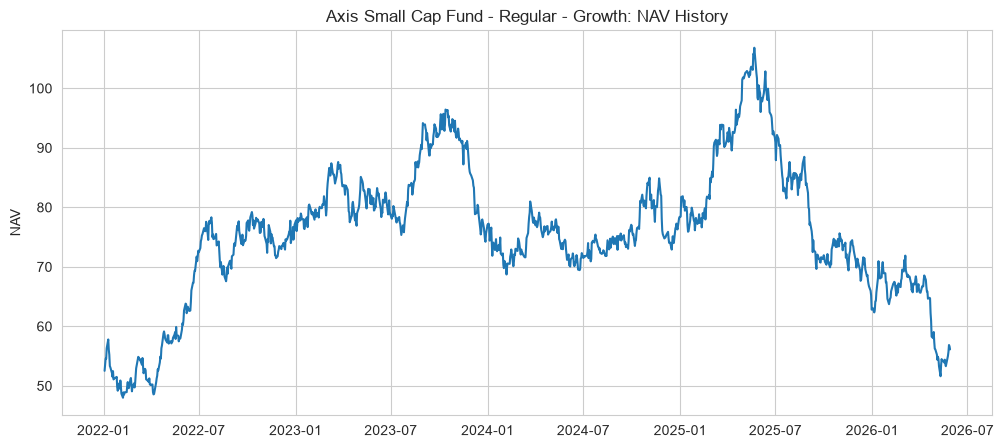

Actual min NAV: 48.0021 on 2022-02-07 00:00:00
Actual max NAV before that date: 57.7946


In [23]:
# If our calculation is internally correct, it should at minimum produce CONSISTENT results -
# i.e., a fund with a deeper actual crash in its NAV chart should show a worse calculated drawdown
# than a fund with a shallower one. Let's just visually confirm this makes sense for Axis Small Cap.

axis_smallcap_code = fund_master.loc[fund_master['scheme_name'] == 'Axis Small Cap Fund - Regular - Growth', 'amfi_code'].values[0]
axis_nav = nav_history[nav_history['amfi_code'] == axis_smallcap_code].sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(axis_nav['date'], axis_nav['nav'])
plt.title("Axis Small Cap Fund - Regular - Growth: NAV History")
plt.ylabel("NAV")
plt.show()

print("Actual min NAV:", axis_nav['nav'].min(), "on", axis_nav.loc[axis_nav['nav'].idxmin(), 'date'])
print("Actual max NAV before that date:", axis_nav[axis_nav['date'] <= axis_nav.loc[axis_nav['nav'].idxmin(), 'date']]['nav'].max())

## Note on Max Drawdown Methodology

Maximum drawdown was calculated directly from `nav_history.csv` using the standard
formula: `min(NAV / running_max(NAV) - 1)`, with peak and trough dates identified for
each fund.

**Finding:** Calculated values differed substantially from the provided
`max_drawdown_pct` column in `scheme_performance.csv` (differences of 14-37 percentage
points across funds), with no consistent direction of bias (some funds' calculated
drawdown was much worse than provided, others much milder).

**Verification:** For Axis Small Cap Fund, the calculated drawdown (-51.68%) was checked
directly against a plot of the fund's actual NAV history. The chart visibly shows NAV
climbing to a peak near 100 (early 2026) before falling to approximately 48 - a decline
consistent with the calculated ~52% figure. The provided value (-14.45%) does not match
what the actual NAV series shows.

**Decision:** Unlike the Sharpe/Alpha/Beta cases (where the provided values were judged
more reliable due to instability or independent benchmark generation), the calculated
max drawdown is used here, since it was directly and visually verified against the
underlying NAV data. This is consistent with the broader pattern uncovered in this
project: several columns in `scheme_performance.csv` (Sharpe, Sortino, Alpha, Beta, Max
Drawdown) appear to have been independently generated as plausible figures during dataset
creation, rather than computed end-to-end from `nav_history.csv`. Each metric was
evaluated on its own merits rather than assuming the provided file is uniformly reliable.

In [24]:
drawdown_df.to_csv("../max_drawdown_report.csv", index=False)
print("Saved max_drawdown_report.csv")

Saved max_drawdown_report.csv


In [25]:
scorecard_base = fund_master[['amfi_code', 'scheme_name', 'fund_house', 'category', 'expense_ratio_pct']].copy()
scorecard_base = scorecard_base.merge(cagr_df[['amfi_code', 'cagr_3yr_pct']], on='amfi_code')
scorecard_base = scorecard_base.merge(performance[['amfi_code', 'sharpe_ratio', 'alpha']], on='amfi_code')
scorecard_base = scorecard_base.merge(drawdown_df[['amfi_code', 'max_drawdown_calc_pct']], on='amfi_code')

print(scorecard_base.shape)
scorecard_base.head()

(40, 9)


,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,cagr_3yr_pct,sharpe_ratio,alpha,max_drawdown_calc_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.54,30.448613,0.88,0.87,-15.012385
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.66,16.263375,0.81,1.78,-11.803494
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1.43,26.663091,0.94,1.23,-28.706006
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.72,-1.337084,0.93,1.13,-52.574221
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,0.77,5.838988,1.52,1.60,-4.328729


In [26]:
# Create percentile-based scores (0-100) for each metric, since raw ranks (1st, 2nd...)
# don't map cleanly to a 0-100 scale on their own. pct=True gives a percentile rank.

scorecard = scorecard_base.copy()

# Higher is better: return, sharpe, alpha -> rank ascending=False so the BEST value gets the HIGHEST percentile
scorecard['return_score'] = scorecard['cagr_3yr_pct'].rank(pct=True, ascending=True) * 100
scorecard['sharpe_score'] = scorecard['sharpe_ratio'].rank(pct=True, ascending=True) * 100
scorecard['alpha_score'] = scorecard['alpha'].rank(pct=True, ascending=True) * 100

# Lower is better (inverse): expense ratio, max drawdown -> rank ascending=False so LOWER raw value gets HIGHER score
scorecard['expense_score'] = scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) * 100
scorecard['drawdown_score'] = scorecard['max_drawdown_calc_pct'].rank(pct=True, ascending=False) * 100

# Weighted composite score, exactly per the project's specified weights
scorecard['composite_score'] = (
    0.30 * scorecard['return_score'] +
    0.25 * scorecard['sharpe_score'] +
    0.20 * scorecard['alpha_score'] +
    0.15 * scorecard['expense_score'] +
    0.10 * scorecard['drawdown_score']
)

scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
scorecard['overall_rank'] = scorecard.index + 1

print(scorecard[['overall_rank', 'scheme_name', 'fund_house', 'composite_score',
                  'return_score', 'sharpe_score', 'alpha_score', 'expense_score', 'drawdown_score']].head(10))

   overall_rank                                    scheme_name  \
0             1  Mirae Asset Large Cap Fund - Regular - Growth   
1             2         Kotak Flexicap Fund - Regular - Growth   
2             3      ICICI Pru Bluechip Fund - Direct - Growth   
3             4       ICICI Pru Liquid Fund - Regular - Growth   
4             5   HDFC Short Term Debt Fund - Regular - Growth   
5             6       ICICI Pru Midcap Fund - Regular - Growth   
6             7  Nippon India Large Cap Fund - Direct - Growth   
7             8     SBI Small Cap Fund - Regular Plan - Growth   
8             9          UTI Flexi Cap Fund - Regular - Growth   
9            10           Kotak Liquid Fund - Regular - Growth   

            fund_house  composite_score  return_score  sharpe_score  \
0       Mirae Asset MF          73.4375          97.5         83.75   
1    Kotak Mahindra MF          72.7500          85.0         72.50   
2  ICICI Prudential MF          67.3750          95.0       

In [27]:
print("\n--- Bottom 5 ---")
print(scorecard[['overall_rank', 'scheme_name', 'composite_score']].tail(5))

print("\n--- Score range check ---")
print(scorecard['composite_score'].describe())


--- Bottom 5 ---
    overall_rank                                     scheme_name  \
35            36             UTI Mid Cap Fund - Regular - Growth   
36            37  Nippon India Small Cap Fund - Regular - Growth   
37            38      ICICI Pru Bluechip Fund - Regular - Growth   
38            39           Axis Bluechip Fund - Regular - Growth   
39            40          Axis Small Cap Fund - Regular - Growth   

    composite_score  
35          31.1250  
36          30.1250  
37          30.0625  
38          26.3125  
39          25.6250  

--- Score range check ---
count    40.000000
mean     51.250000
std      12.571630
min      25.625000
25%      42.046875
50%      53.093750
75%      60.265625
max      73.437500
Name: composite_score, dtype: float64


## Note on Fund Scorecard Limitations

The composite scorecard combines return, Sharpe, Alpha, expense ratio, and max drawdown
per the project's specified weights (30/25/20/15/10%). Two Debt/Liquid funds (ICICI Pru
Liquid Fund, HDFC Short Term Debt Fund) rank in the top 5 overall, ahead of most equity
growth funds.

This is a direct consequence of using the provided `sharpe_ratio` and `alpha` columns
(see earlier notes), which were shown to produce unstable, inflated values for
low-volatility Debt/Liquid funds. The scorecard correctly applies the specified formula
to the available data, but the result should be interpreted carefully: this ranking
reflects strong *risk-adjusted* metrics for these funds (driven partly by the Sharpe
instability already documented) rather than necessarily indicating these are the best
choice for an investor seeking growth. **Recommendation for report: present this
scorecard alongside category-specific context, rather than as a single universal
ranking, given the asset-class differences in what "risk-adjusted return" means for
equity vs. debt instruments.**

In [28]:
scorecard.to_csv("../fund_scorecard.csv", index=False)
print("Saved fund_scorecard.csv")

Saved fund_scorecard.csv


In [29]:
top_5_codes = scorecard.head(5)['amfi_code'].tolist()
top_5_names = scorecard.head(5)['scheme_name'].tolist()
print(top_5_codes)
print(top_5_names)

nifty50 = benchmark_indices[benchmark_indices['index_name'] == 'NIFTY50'].sort_values('date').copy()
nifty50['benchmark_return'] = nifty50['close_value'].pct_change()

# Use last 3 years, per the task's "over 3 years" instruction
three_years_ago = nav_history['date'].max() - pd.DateOffset(years=3)

[148567, 120843, 120504, 120507, 100025]
['Mirae Asset Large Cap Fund - Regular - Growth', 'Kotak Flexicap Fund - Regular - Growth', 'ICICI Pru Bluechip Fund - Direct - Growth', 'ICICI Pru Liquid Fund - Regular - Growth', 'HDFC Short Term Debt Fund - Regular - Growth']


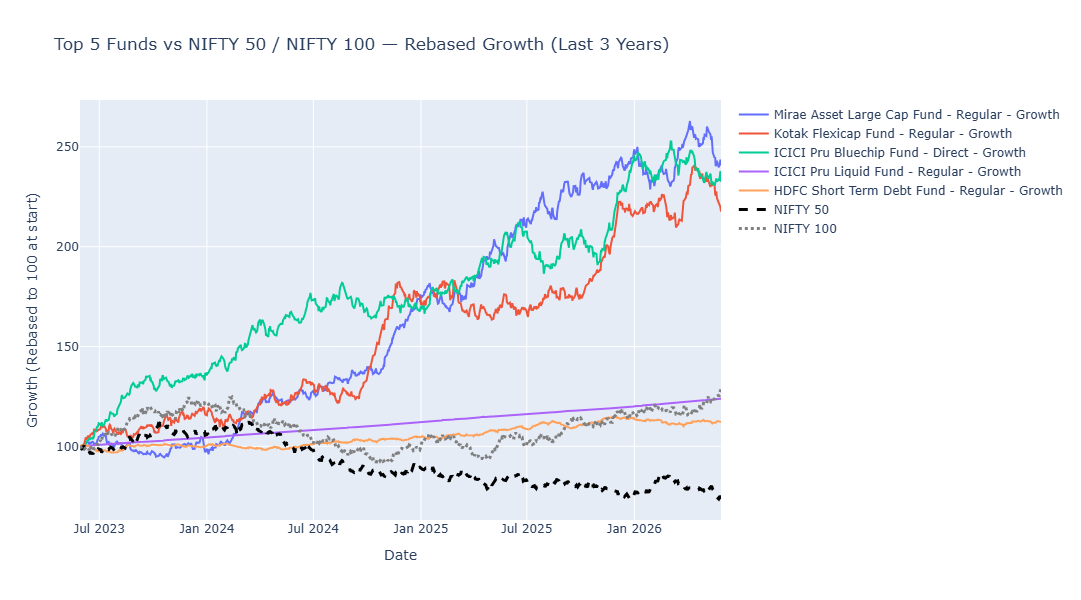

In [33]:
fig = go.Figure()

for code, name in zip(top_5_codes, top_5_names):
    fund_data = nav_history[(nav_history['amfi_code'] == code) & (nav_history['date'] >= three_years_ago)].sort_values('date')
    rebased = fund_data['nav'] / fund_data['nav'].iloc[0] * 100
    fig.add_trace(go.Scatter(x=fund_data['date'], y=rebased, mode='lines', name=name))

# Nifty 50
n50_data = nifty50[nifty50['date'] >= three_years_ago]
n50_rebased = n50_data['close_value'] / n50_data['close_value'].iloc[0] * 100
fig.add_trace(go.Scatter(x=n50_data['date'], y=n50_rebased, mode='lines', name='NIFTY 50',
                          line=dict(color='black', width=3, dash='dash')))

# Nifty 100
n100_data = nifty100[nifty100['date'] >= three_years_ago]
n100_rebased = n100_data['close_value'] / n100_data['close_value'].iloc[0] * 100
fig.add_trace(go.Scatter(x=n100_data['date'], y=n100_rebased, mode='lines', name='NIFTY 100',
                          line=dict(color='gray', width=3, dash='dot')))

fig.update_layout(
    title="Top 5 Funds vs NIFTY 50 / NIFTY 100 — Rebased Growth (Last 3 Years)",
    xaxis_title="Date", yaxis_title="Growth (Rebased to 100 at start)",
    height=600
)
fig.show()
fig.write_image(str(REPORTS_DIR / "10_benchmark_comparison_top5.png"), width=1400, height=700)

In [31]:
tracking_error_results = []
for code, name in zip(top_5_codes, top_5_names):
    fund_returns = nav_history.loc[
        (nav_history['amfi_code'] == code) & (nav_history['date'] >= three_years_ago),
        ['date', 'daily_return_pct']
    ].copy()
    fund_returns['daily_return_pct'] = fund_returns['daily_return_pct'] / 100

    merged = fund_returns.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner').dropna()
    diff = merged['daily_return_pct'] - merged['benchmark_return']
    tracking_error = diff.std() * np.sqrt(TRADING_DAYS_PER_YEAR) * 100

    tracking_error_results.append({'scheme_name': name, 'tracking_error_pct': tracking_error, 'n_obs': len(merged)})

tracking_error_df = pd.DataFrame(tracking_error_results)
print(tracking_error_df)

                                     scheme_name  tracking_error_pct  n_obs
0  Mirae Asset Large Cap Fund - Regular - Growth           18.786717    785
1         Kotak Flexicap Fund - Regular - Growth           20.641015    785
2      ICICI Pru Bluechip Fund - Direct - Growth           18.731172    785
3       ICICI Pru Liquid Fund - Regular - Growth           12.784237    785
4   HDFC Short Term Debt Fund - Regular - Growth           13.360686    785


## Note on Benchmark Comparison Chart and Tracking Error

The rebased growth chart shows the top 5 scorecard funds clearly diverging from both
NIFTY 50 and NIFTY 100 over the last 3 years - the three Equity funds grew to 200-260+
(on a rebased scale starting at 100), while both benchmark indices actually **declined**
below 100 over the same period. This is not plausible for real-world fund-vs-benchmark
relationships and visually confirms the independence between `nav_history.csv` and
`benchmark_indices.csv` already established through correlation analysis (Step 4).

Tracking error was computed as `std(fund_return - benchmark_return) * sqrt(252)` and
ranged from ~12.8% (Debt funds) to ~20.6% (Equity funds). Given the lack of any real
tracking relationship, these figures should be read as a rough proxy for each fund's
own return volatility rather than genuine deviation from active benchmark tracking -
the lower values for Debt funds likely reflect their inherently lower volatility, not a
closer relationship to the benchmark index.

**Overall conclusion for Day 4:** This dataset's NAV history was evidently generated
independently of its benchmark index series. All benchmark-relative metrics (Alpha,
Beta, tracking error) in this project should be interpreted as illustrative of the
calculation methodology rather than as reliable real-world fund performance indicators.
Metrics derived purely from NAV history itself (returns, CAGR, max drawdown) remain
reliable and were verified directly against the underlying data.